# Hyperparameter Black-Scholes
## Learning rate

In [7]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools

In [8]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/fys5429/code/notebooks


In [9]:
# Pathways
data_path = Path("..") / "data" / "generated" / "bs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [10]:
# Importing BSPINN() Class
import sys
sys.path.insert(0, "../scripts")
from bspinn import BSPINN
from train_bs import train_pinn

### Global parameters

In [11]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics
K = 100.0
r = 0.05
sigma = 0.20
T_max = 1.0
S_max = 300.0

# NN (update from sweep 1 winner if different)
HIDDEN_LAYERS = 2
NEURONS_PER_LAYER = 256

# PINN Loss Weights
LAMBDA_PDE = 20.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

# Sweep values
LR_VALUES    = [1e-4, 3e-4, 5e-4, 1e-3, 3e-3]
SWEEP_EPOCHS = 5000

Using device: cuda


In [12]:
# Check if data exists and has the right S range, otherwise regenerate
if data_path.exists():
    df_all = pd.read_parquet(data_path)
    s_range = df_all['S'].max()
    if s_range < S_max * 0.9:
        print(f"Existing data has S_max={s_range:.0f}, expected ~{S_max:.0f}. Regenerating...")
        data_path.unlink()

if not data_path.exists():
    print(f"Generating collocation data with S_max={S_max}, T_max={T_max}...")

    N_INTERIOR = 2000
    N_BOUNDARY = 500

    S_interior = torch.rand(N_INTERIOR, 1) * S_max
    tau_interior = torch.rand(N_INTERIOR, 1) * T_max

    S_ic_gen = torch.rand(N_BOUNDARY, 1) * S_max
    tau_ic_gen = torch.zeros(N_BOUNDARY, 1)

    S_bc_gen = torch.zeros(N_BOUNDARY, 1)
    tau_bc_gen = torch.rand(N_BOUNDARY, 1) * T_max

    df_all = pd.concat([
        pd.DataFrame({'S': S_interior.numpy().flatten(),
                       'tau': tau_interior.numpy().flatten(),
                       'point_type': 'interior'}),
        pd.DataFrame({'S': S_ic_gen.numpy().flatten(),
                       'tau': tau_ic_gen.numpy().flatten(),
                       'point_type': 'initial_condition'}),
        pd.DataFrame({'S': S_bc_gen.numpy().flatten(),
                       'tau': tau_bc_gen.numpy().flatten(),
                       'point_type': 'boundary_condition'}),
    ], ignore_index=True)

    data_path.parent.mkdir(parents=True, exist_ok=True)
    df_all.to_parquet(data_path)
    print(f"Saved to {data_path}")
else:
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, tau_ic = extract_tensors(df_ic)

df_bc = df_all[df_all['point_type'] == 'boundary_condition']
S_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")

Existing data has S_max=150, expected ~300. Regenerating...
Generating collocation data with S_max=300.0, T_max=1.0...
Saved to ../data/generated/bs_collocation.parquet
Interior points: 2000
IC points:       500
BC points:       500


In [13]:
sweep_results = []
start_time = time.time()
total_runs = len(LR_VALUES)

header = f"{'#':>3} | {'LR':>10} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, lr in enumerate(LR_VALUES):
    run_start = time.time()
    result = train_pinn(S_in, tau_in, S_ic, tau_ic, S_bc, tau_bc,
                    sigma, r, K, device,
                    LAMBDA_PDE, LAMBDA_IC, LAMBDA_BC, SWEEP_EPOCHS,
                    lr=lr, hidden_layers=HIDDEN_LAYERS, neurons=NEURONS_PER_LAYER,
                    activation='tanh')

    result['lr'] = lr
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {lr:>10.1e} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")

  # |         LR |     PDE Loss      IC Loss      BC Loss |   Time      ETA
───────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  1 |    1.0e-04 |     0.831653  1529.420288     0.073149 |    52s    207s
  2 |    3.0e-04 |     0.005614     0.114377     0.001480 |    46s    146s
  3 |    5.0e-04 |     0.004255     0.052971     0.001302 |    46s     96s
  4 |    1.0e-03 |     0.005340     0.047053     0.001344 |    46s     47s
  5 |    3.0e-03 |     0.005709     0.045966     0.001266 |    45s      0s
───────────────────────────────────────────────────────────────────────────
Sweep complete: 5 runs in 3m 54s


In [14]:
df_sweep = pd.DataFrame([{
    'lr': r['lr'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

df_sweep = df_sweep.sort_values('pde_loss')
print(df_sweep.to_string(index=False))

    lr  pde_loss     ic_loss  bc_loss   total_loss
0.0005  0.004255    0.052971 0.001302     0.621326
0.0010  0.005340    0.047053 0.001344     0.584040
0.0003  0.005614    0.114377 0.001480     1.263448
0.0030  0.005709    0.045966 0.001266     0.580165
0.0001  0.831653 1529.420288 0.073149 15311.202148


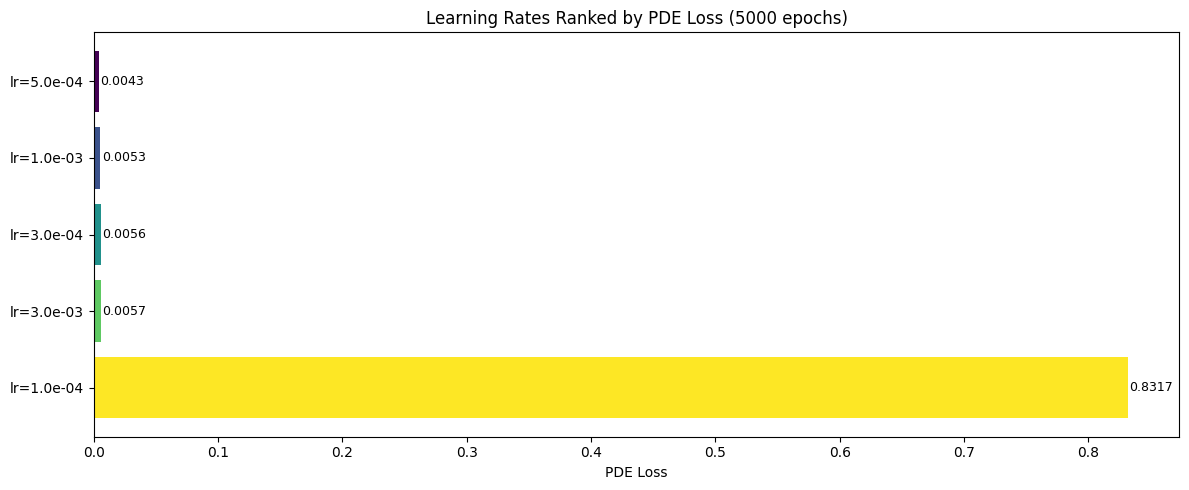

In [15]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
labels = [f"lr={r['lr']:.1e}" for _, r in df_ranked.iterrows()]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ranked)))
bars = ax.barh(range(len(df_ranked)), df_ranked['pde_loss'], color=colors)
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels(labels)
ax.set_xlabel('PDE Loss')
ax.set_title(f'Learning Rates Ranked by PDE Loss ({SWEEP_EPOCHS} epochs)')
ax.invert_yaxis()

for i, v in enumerate(df_ranked['pde_loss']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_lr_ranked.pdf", bbox_inches="tight")
plt.show()

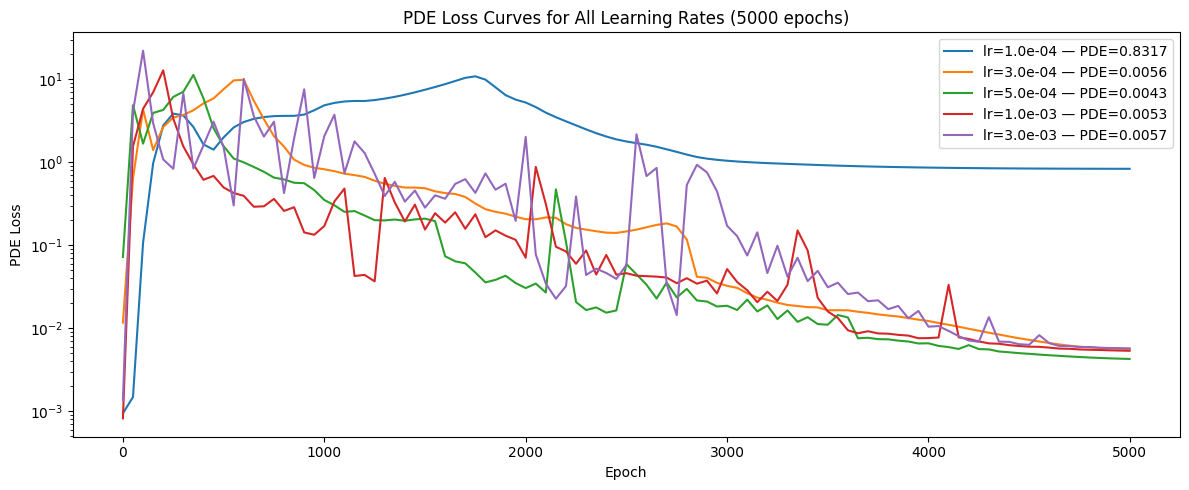

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

for r in sweep_results:
    label = f"lr={r['lr']:.1e} — PDE={r['final_pde']:.4f}"
    ax.plot(r['history']['epoch'], r['history']['pde'], label=label)

ax.set_xlabel('Epoch')
ax.set_ylabel('PDE Loss')
ax.set_title(f'PDE Loss Curves for All Learning Rates ({SWEEP_EPOCHS} epochs)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(out_dir / "hyper_bs_lr_curves.pdf", bbox_inches="tight")
plt.show()

In [17]:
if IN_COLAB:
    print(f"Plots already saved to Google Drive: {out_dir}")
else:
    print(f"PDFs saved locally to: {out_dir.resolve()}")

Plots already saved to Google Drive: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda
